## longseq example
#### longseq 
- 더 긴 문장 데이터셋을 이용하기 싶음
- 아주 긴 문장을 하나의 인풋으로 사용할 수 없음. => *특정 사이즈로 잘라서 사용*

#### making sequence dataset from long sentence
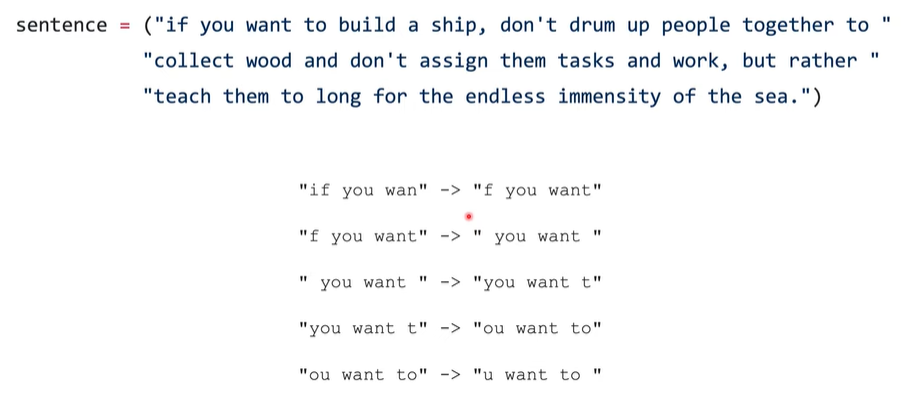

In [1]:
import torch
import torch.nn as nn 
import torch.optim as optim
import numpy as np

torch.manual_seed(0)

In [2]:
sentence = ("if you want to build a ship, don't drum up people together to "
            "collect wood and don't assign them tasks and work, but rather "
            "teach them to long for the endless immensity of the sea.")

In [3]:
char_set = list(set(sentence))
char_dic = {c: i for i, c in enumerate(char_set)}

In [ ]:
dic_size = len(char_dic)
hidden_size = len(char_dic)
sequence_length = 10 # 임의의 값
learning_rate = 0.1

In [5]:
x_data = []
y_data = []

for i in range(0, len(sentence) - sequence_length):
    x_str = sentence[i:i+sequence_length]
    y_str = sentence[i + 1: i + sequence_length + 1]

    print(i, x_str, '->', y_str)
    x_data.append([char_dic[c] for c in x_str])
    y_data.append([char_dic[c] for c in y_str])

x_one_hot = [np.eye(dic_size)[x] for x in x_data]

# transforms as torch tensor variable
X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)

0 if you wan -> f you want
1 f you want ->  you want 
2  you want  -> you want t
3 you want t -> ou want to
4 ou want to -> u want to 
5 u want to  ->  want to b
6  want to b -> want to bu
7 want to bu -> ant to bui
8 ant to bui -> nt to buil
9 nt to buil -> t to build
10 t to build ->  to build 
11  to build  -> to build a
12 to build a -> o build a 
13 o build a  ->  build a s
14  build a s -> build a sh
15 build a sh -> uild a shi
16 uild a shi -> ild a ship
17 ild a ship -> ld a ship,
18 ld a ship, -> d a ship, 
19 d a ship,  ->  a ship, d
20  a ship, d -> a ship, do
21 a ship, do ->  ship, don
22  ship, don -> ship, don'
23 ship, don' -> hip, don't
24 hip, don't -> ip, don't 
25 ip, don't  -> p, don't d
26 p, don't d -> , don't dr
27 , don't dr ->  don't dru
28  don't dru -> don't drum
29 don't drum -> on't drum 
30 on't drum  -> n't drum u
31 n't drum u -> 't drum up
32 't drum up -> t drum up 
33 t drum up  ->  drum up p
34  drum up p -> drum up pe
35 drum up pe -> rum up peo
36

C:\Users\User\AppData\Local\Temp\ipykernel_6208\2825722165.py:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  X = torch.FloatTensor(x_one_hot)


### RNN을 스택킹하고 FC를 마지막에 추가하는 모델
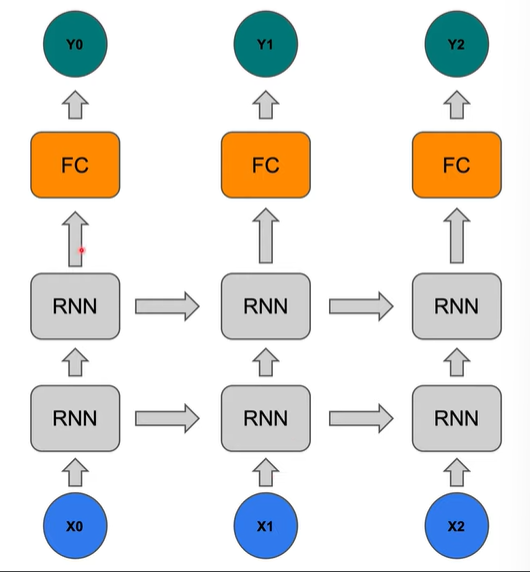
- fc가 필요한 이유 : RNN이 찾은 복잡한 특징들을 우리가 원하는 출력 규격으로 맞추기 위함

In [9]:
class Net(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, layers):
        super(Net, self).__init__()
        # 1. RNN 레이어 설정
        # input_dim: 들어오는 문자(또는 데이터)의 종류 개수 (예: dic_size)
        # hidden_dim: RNN 내부에서 데이터를 처리할 때 사용하는 '메모리 공간'의 크기
        # num_layers: 그림에서 보신 것처럼 RNN을 위로 몇 층 쌓을 것인지 (여기서는 2층)
        # batch_first=True: 데이터의 형태를 [배치사이즈, 시간, 데이터] 순서로 받겠다는 설정
        self.rnn = torch.nn.RNN(input_dim, hidden_dim, num_layers=layers, batch_first=True)

        # 2. FC(Fully Connected) 레이어 설정
        # 첫 번째 파라미터(hidden_dim): RNN이 내뱉는 결과물의 크기가 hidden_dim이므로, 
        # 그것을 그대로 받아오기 위해 크기를 맞춘 것입니다. (입력 크기)
        # 두 번째 파라미터(hidden_dim): 최종적으로 내뱉을 결과의 크기입니다. 
        # 만약 '다음 글자'를 맞추는 게 목적이라면 보통 여기서 dic_size를 넣어주기도 합니다.
        self.fc = torch.nn.Linear(hidden_dim, hidden_dim, bias=True)

    
    def forward(self, x):
        x, _status = self.rnn(x)
        x = self.fc(x)

        return x

net = Net(dic_size, hidden_size, 2)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), learning_rate)

# start training
for i in range(1000):
    optimizer.zero_grad()
    outputs = net(X)
    loss = criterion(outputs.view(-1, dic_size), Y.view(-1))
    loss.backward()
    optimizer.step()

    # 모델이 예측한 결과물 해석하는 파트
    results = outputs.argmax(dim=2)
    predict_str = ''
    for j, result in enumerate(results):
        print(i, j, ''.join([char_set[t] for t in result]), loss.item()) # 숫자를 문자로
        if j == 0: # 맨 처음에는 sequence_length 길이 만큼을 만듦. (many-to-many에서 사용)
            # 데이터를 한 칸씩 밀어가며 학습할 때 중복을 피하기 위함.
            predict_str += ''.join([char_set[t] for t in result])
        else: # 그 이후 부터는 제일 마지막 거 계속 붙여서 만듦.
            predict_str += char_set[result[-1]]

0 0 uu   '  uu 3.2159082889556885
0 1 '   '  uu' 3.2159082889556885
0 2 '  '  uu'  3.2159082889556885
0 3 iu'  uu'   3.2159082889556885
0 4 '    u'    3.2159082889556885
0 5 '  uu'     3.2159082889556885
0 6 'uuu'      3.2159082889556885
0 7 'uu'       3.2159082889556885
0 8 iu'        3.2159082889556885
0 9 u'       ' 3.2159082889556885
0 10 'u'     '  3.2159082889556885
0 11 'u     ' . 3.2159082889556885
0 12 'u '  ' .u 3.2159082889556885
0 13 ' '  ' .u. 3.2159082889556885
0 14 'u' ' .u.' 3.2159082889556885
0 15 .u ' .u.'  3.2159082889556885
0 16 ' ' .u.'   3.2159082889556885
0 17 u'u.u.'  u 3.2159082889556885
0 18 'u.u.'  u' 3.2159082889556885
0 19 'uu.'  u'  3.2159082889556885
0 20 'u.'  u'   3.2159082889556885
0 21 iu'  u'  . 3.2159082889556885
0 22 ''  u'  .u 3.2159082889556885
0 23 '  u'   u' 3.2159082889556885
0 24 i u'   u'  3.2159082889556885
0 25 uu'    '   3.2159082889556885
0 26 u'    '    3.2159082889556885
0 27 ' .'u'   . 3.2159082889556885
0 28 'u.u'   .' 3.215908288955